In [108]:
%load_ext autoreload
%autoreload 2

In [130]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import k_armed_bandit as bandit

## Greedy vs Epsilon greedy algorithms for stationary cases

In [232]:
n_arms = 10
n_steps = 1000
n_iterations = 2000

bandit_stationary_env = bandit.Bandit_Env(
    n_arms = n_arms,
    bandit_args = { 'q_true_var': 1, 'reward_var': 1, 'is_non_stationary': False }
)

In [132]:
actor_map = {
    'Greedy': {
        'n_arms': n_arms,
        'bandit_env': bandit_stationary_env,
        'policy_fn': "greedy",
        'update_fn': "sample_average",
        'policy_args': {  }
    },
    'Epsilon 0.1': {
        'n_arms': n_arms,
        'bandit_env': bandit_stationary_env,
        'policy_fn': "epsilon_greedy",
        'update_fn': "sample_average",
        'policy_args': { 'epsilon': 0.1 }
    },
    'Epsilon 0.01': {
        'n_arms': n_arms,
        'bandit_env': bandit_stationary_env,
        'policy_fn': "epsilon_greedy",
        'update_fn': "sample_average",
        'policy_args': { 'epsilon': 0.01 }
    },
}

In [133]:
experiment_results = bandit.run_bandit_experiments(actor_map, n_steps, n_iterations)

rewards_map = experiment_results['rewards']
best_action_perct_map = experiment_results['best_action_perct']
mse_map = experiment_results['mse']

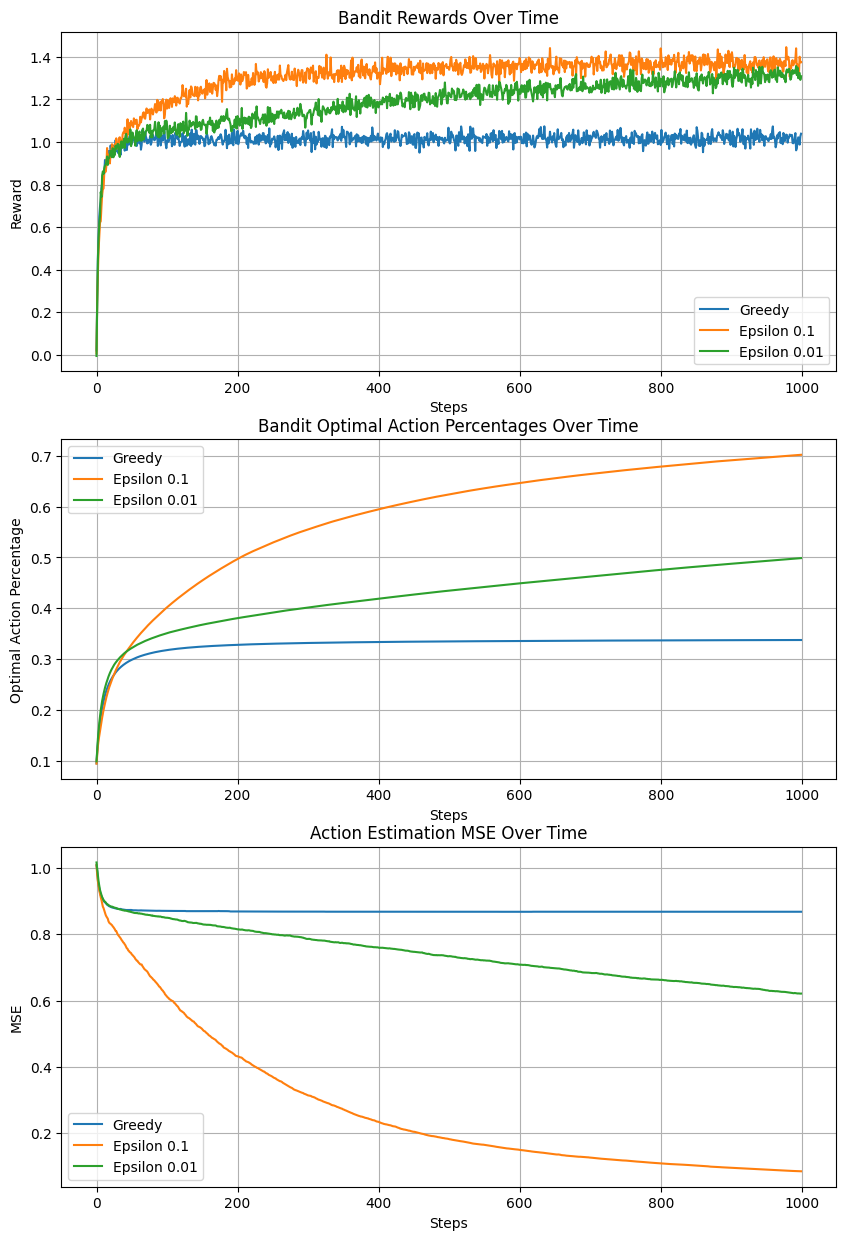

In [134]:
bandit.diagnostic_plots(actor_map, rewards_map, best_action_perct_map, mse_map)

## Non Stationary k-armed Bandit Problem

In [239]:
bandit_non_stationary_env = bandit.Bandit_Env(
    n_arms = n_arms,
    bandit_args = { 'q_true_var': 0.01, 'reward_var': 1, 'is_non_stationary': True }
)

In [157]:
actor_map = {
    'Epsilon 0.1': {
        'n_arms': n_arms,
        'bandit_env': bandit_non_stationary_env,
        'policy_fn': "epsilon_greedy",
        'update_fn': "sample_average",
        'policy_args': { 'epsilon': 0.1 }
    },
    'Epsilon 0.1 Constant Step Size': {
        'n_arms': n_arms,
        'bandit_env': bandit_non_stationary_env,
        'policy_fn': "epsilon_greedy",
        'update_fn': "constant_step_size",
        'policy_args': { 'epsilon': 0.1 }
    },
}

In [158]:
experiment_results = bandit.run_bandit_experiments(actor_map, n_steps, n_iterations)

rewards_map = experiment_results['rewards']
best_action_perct_map = experiment_results['best_action_perct']
mse_map = experiment_results['mse']

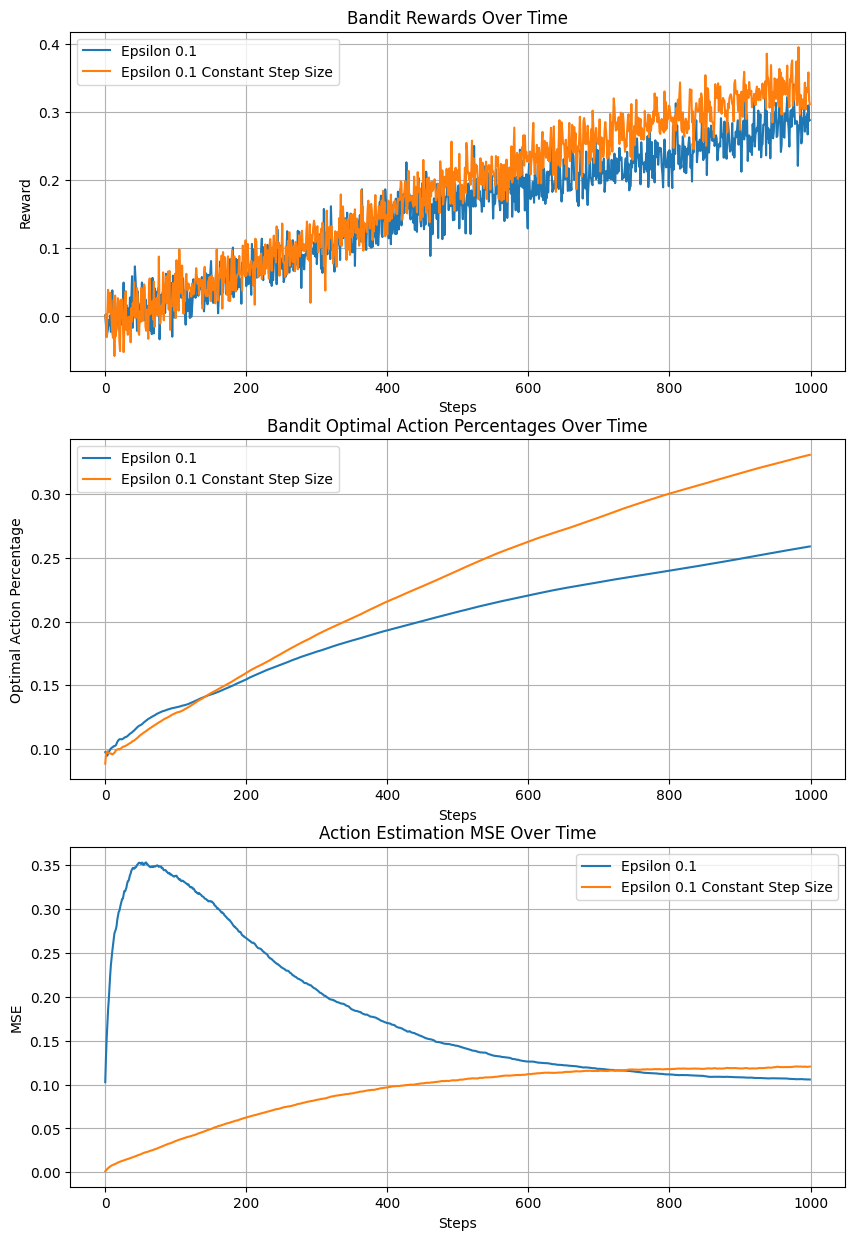

In [159]:
bandit.diagnostic_plots(actor_map, rewards_map, best_action_perct_map, mse_map)

## Optimistic Initial estimates in Stationary case

In [160]:
actor_map = {
    'Epsilon 0.1': {
        'n_arms': n_arms,
        'bandit_env': bandit_stationary_env,
        'policy_fn': "epsilon_greedy",
        'update_fn': "sample_average",
        'policy_args': { 'epsilon': 0.1 }
    },
    'Optimistic Greedy': {
        'n_arms': n_arms,
        'bandit_env': bandit_stationary_env,
        'policy_fn': "greedy",
        'update_fn': "sample_average",
        'policy_args': { 'epsilon': 0.1, 'q_estimate_initial': 5 }
    },
}

In [161]:
experiment_results = bandit.run_bandit_experiments(actor_map, n_steps, n_iterations)

rewards_map = experiment_results['rewards']
best_action_perct_map = experiment_results['best_action_perct']
mse_map = experiment_results['mse']

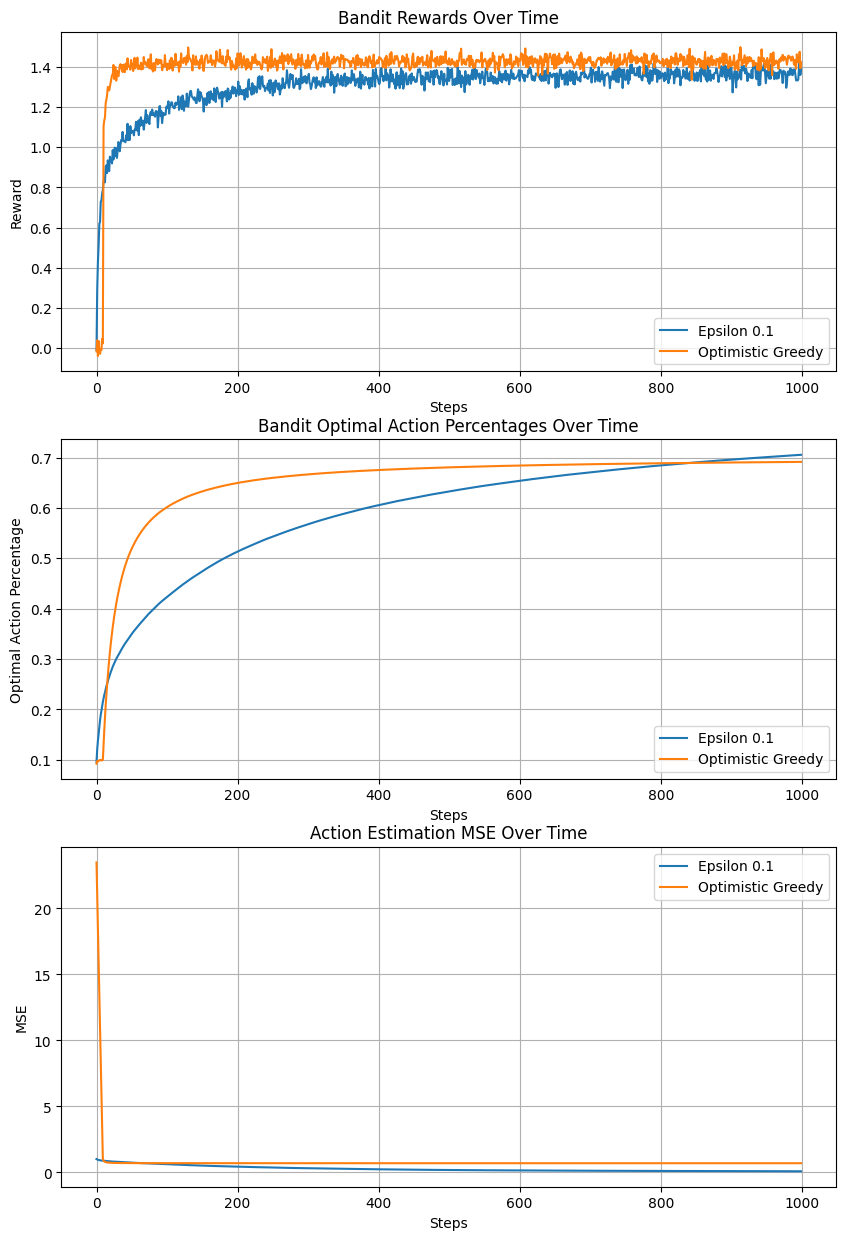

In [162]:
bandit.diagnostic_plots(actor_map, rewards_map, best_action_perct_map, mse_map)

## Unbiased Step Sizes for non-stationary case

In [163]:
actor_map = {
    'Epsilon 0.1 Constant Step Size': {
        'n_arms': n_arms,
        'bandit_env': bandit_non_stationary_env,
        'policy_fn': "epsilon_greedy",
        'update_fn': "constant_step_size",
        'policy_args': { 'epsilon': 0.1 }
    },
    'Epsilon 0.1 Constant Step Size Unbiased': {
        'n_arms': n_arms,
        'bandit_env': bandit_non_stationary_env,
        'policy_fn': "epsilon_greedy",
        'update_fn': "constant_step_size_unbiased",
        'policy_args': { 'epsilon': 0.1 }
    },
}

In [164]:
experiment_results = bandit.run_bandit_experiments(actor_map, n_steps, n_iterations)

rewards_map = experiment_results['rewards']
best_action_perct_map = experiment_results['best_action_perct']
mse_map = experiment_results['mse']

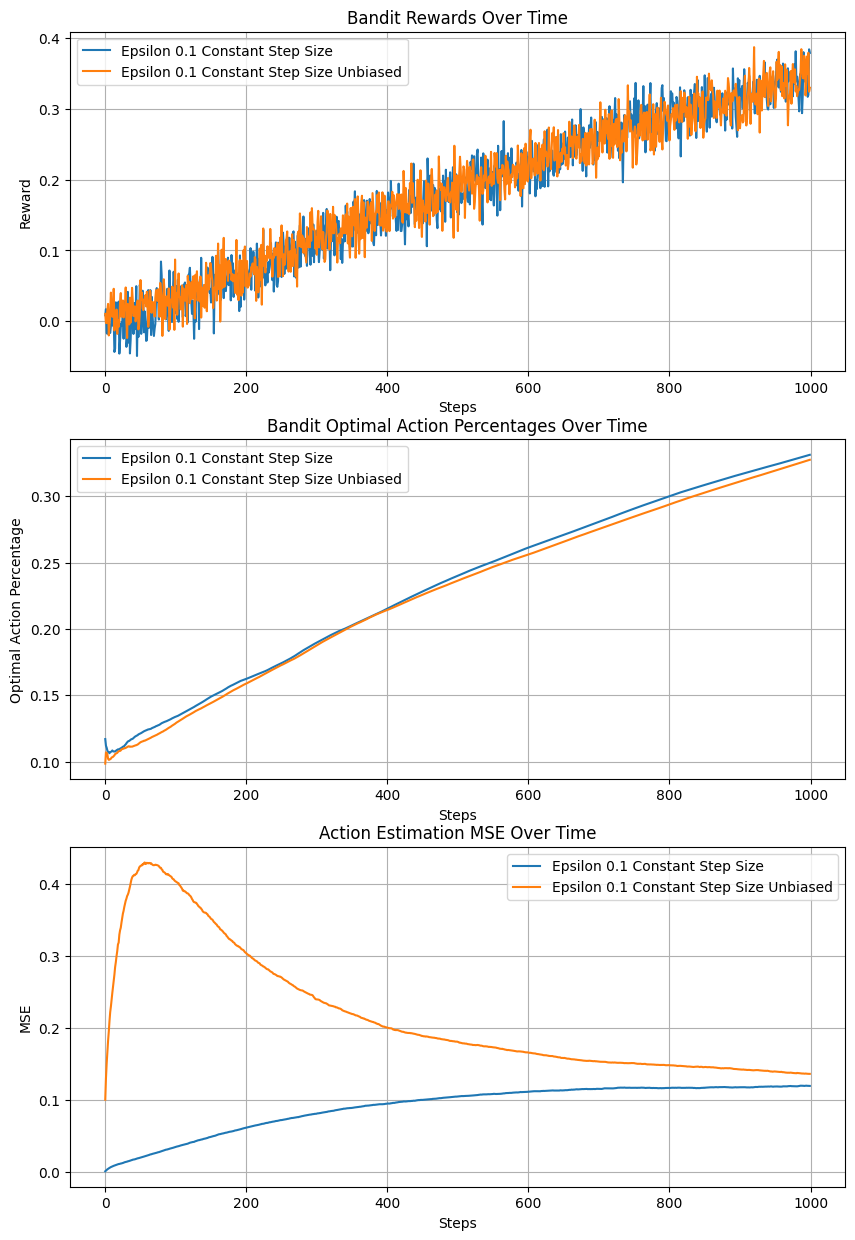

In [165]:
bandit.diagnostic_plots(actor_map, rewards_map, best_action_perct_map, mse_map)

## Upper Confidence Bound policy

In [169]:
actor_map = {
    'Epsilon 0.1': {
        'n_arms': n_arms,
        'bandit_env': bandit_stationary_env,
        'policy_fn': "epsilon_greedy",
        'update_fn': "constant_step_size",
        'policy_args': { 'epsilon': 0.1 }
    },
    'UCB': {
        'n_arms': n_arms,
        'bandit_env': bandit_stationary_env,
        'policy_fn': "upper_cb",
        'update_fn': "constant_step_size",
        'policy_args': { 'confidence': 2 }
    },
}

In [170]:
experiment_results = bandit.run_bandit_experiments(actor_map, n_steps, n_iterations)

rewards_map = experiment_results['rewards']
best_action_perct_map = experiment_results['best_action_perct']
mse_map = experiment_results['mse']

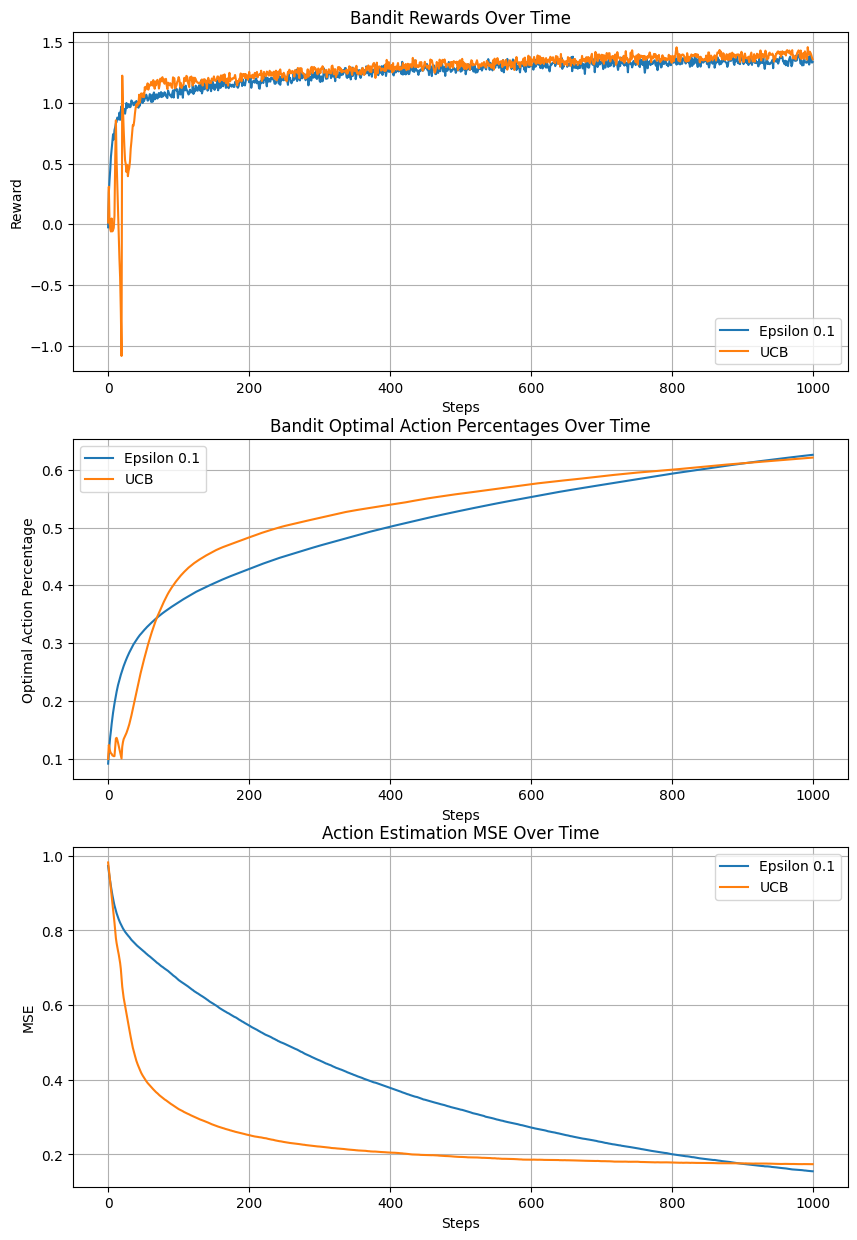

In [171]:
bandit.diagnostic_plots(actor_map, rewards_map, best_action_perct_map, mse_map)

# Gradient Bandit Algorithms

In [210]:
def sga_policy(actor):
    if 'preferences' not in actor.store:
        actor.store['preferences'] = np.zeros(actor.n_arms)
    
    exp_preferences = np.exp(actor.store['preferences'])
    action_probs = exp_preferences / np.sum(exp_preferences)
    
    return np.random.choice(len(actor.q_estimate), p=action_probs)

def sga_update(actor, action, reward):
    if 'preferences' not in actor.store:
        actor.store['preferences'] = np.zeros(actor.n_arms)

    if 'avg_reward' not in actor.store:
        actor.store['avg_reward'] = reward
    else:
        alpha = actor.policy_args.get('alpha', 0.1)
        reward_diff = reward - actor.store['avg_reward']
        exp_preferences = np.exp(actor.store['preferences'])
        action_probs = exp_preferences / np.sum(exp_preferences)
        
        # Update Preferences for all actions
        for a in range(actor.n_arms):
            if a == action: actor.store['preferences'][a] += alpha * reward_diff * (1 - action_probs[a])
            else: actor.store['preferences'][a] -= alpha * reward_diff * action_probs[a]

        # Update average reward for the taken action
        actor.store['avg_reward'] += (1 / actor.total_count) * reward_diff


bandit_env = bandit.Bandit_Env(
    n_arms = n_arms,
    bandit_args = { 'q_true_var': 1, 'q_true_mean': 4, 'reward_var': 1, 'is_non_stationary': False }
)

actor_map = {
    'Epsilon 0.1': {
        'n_arms': n_arms,
        'bandit_env': bandit_env,
        'policy_fn': "epsilon_greedy",
        'update_fn': "sample_average",
        'policy_args': { 'epsilon': 0.1 }
    },
    'Stochastic Gradient Ascent': {
        'n_arms': n_arms,
        'bandit_env': bandit_env,
        'policy_fn': sga_policy,
        'update_fn': sga_update,
        'policy_args': { 'alpha': 0.1 }
    },
}

In [212]:
experiment_results = bandit.run_bandit_experiments(actor_map, n_steps, n_iterations)

rewards_map = experiment_results['rewards']
best_action_perct_map = experiment_results['best_action_perct']
mse_map = experiment_results['mse']

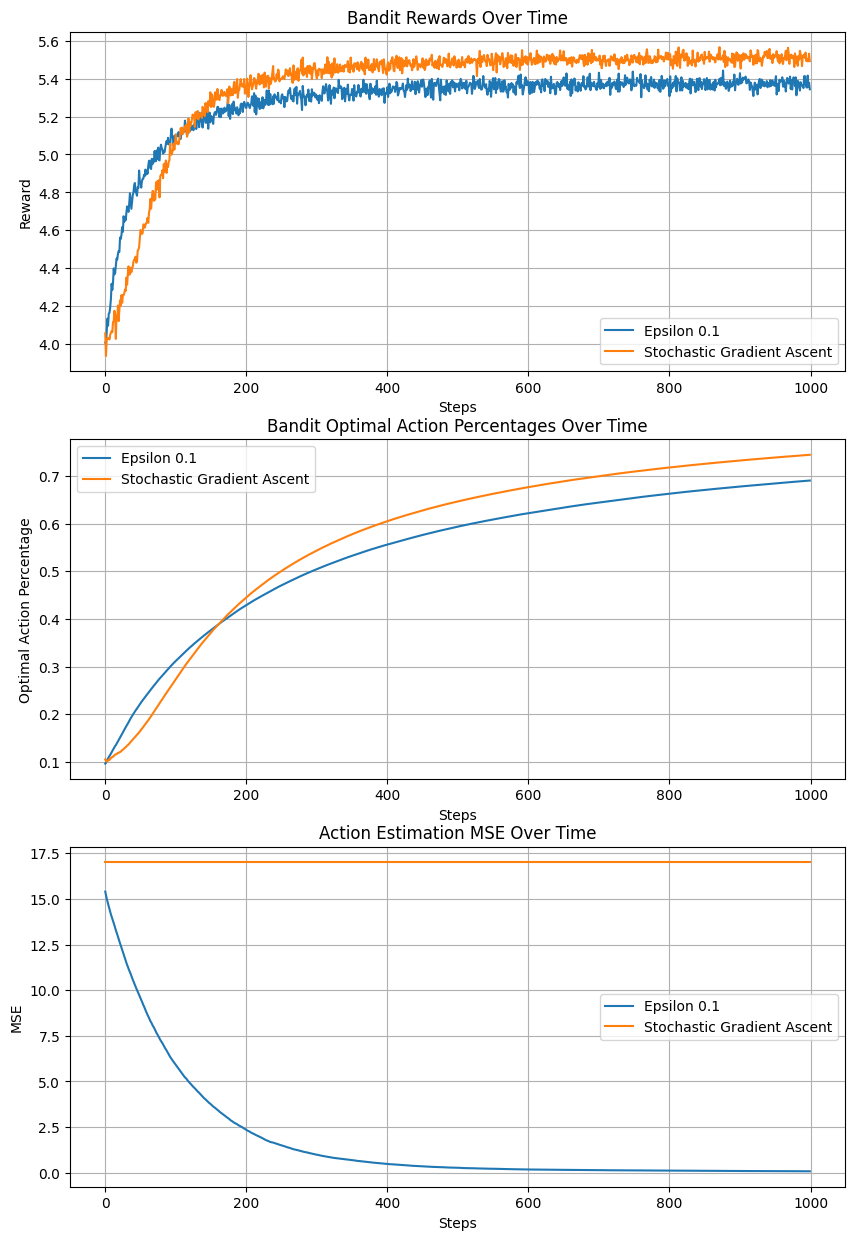

In [213]:
bandit.diagnostic_plots(actor_map, rewards_map, best_action_perct_map, mse_map)

# Parameter Study for non-stationary case

In [249]:
n_steps_params = 200_000
n_iterations_params = 10
epsilons = [1/128, 1/64, 1/32, 1/16, 1/8, 1/4, 1/2, 1, 2, 4]

actor_map = {
    f'Epsilon {epsilon:.2f}': {
        'n_arms': n_arms,
        'bandit_env': bandit_non_stationary_env,
        'policy_fn': "epsilon_greedy",
        'update_fn': "constant_step_size",
        'policy_args': { 'step_size': 0.1, 'epsilon': epsilon }
    } for epsilon in epsilons
}

In [250]:
experiment_results = bandit.run_bandit_experiments(actor_map, n_steps_params, n_iterations_params)

rewards_map = experiment_results['rewards']
best_action_perct_map = experiment_results['best_action_perct']
mse_map = experiment_results['mse']

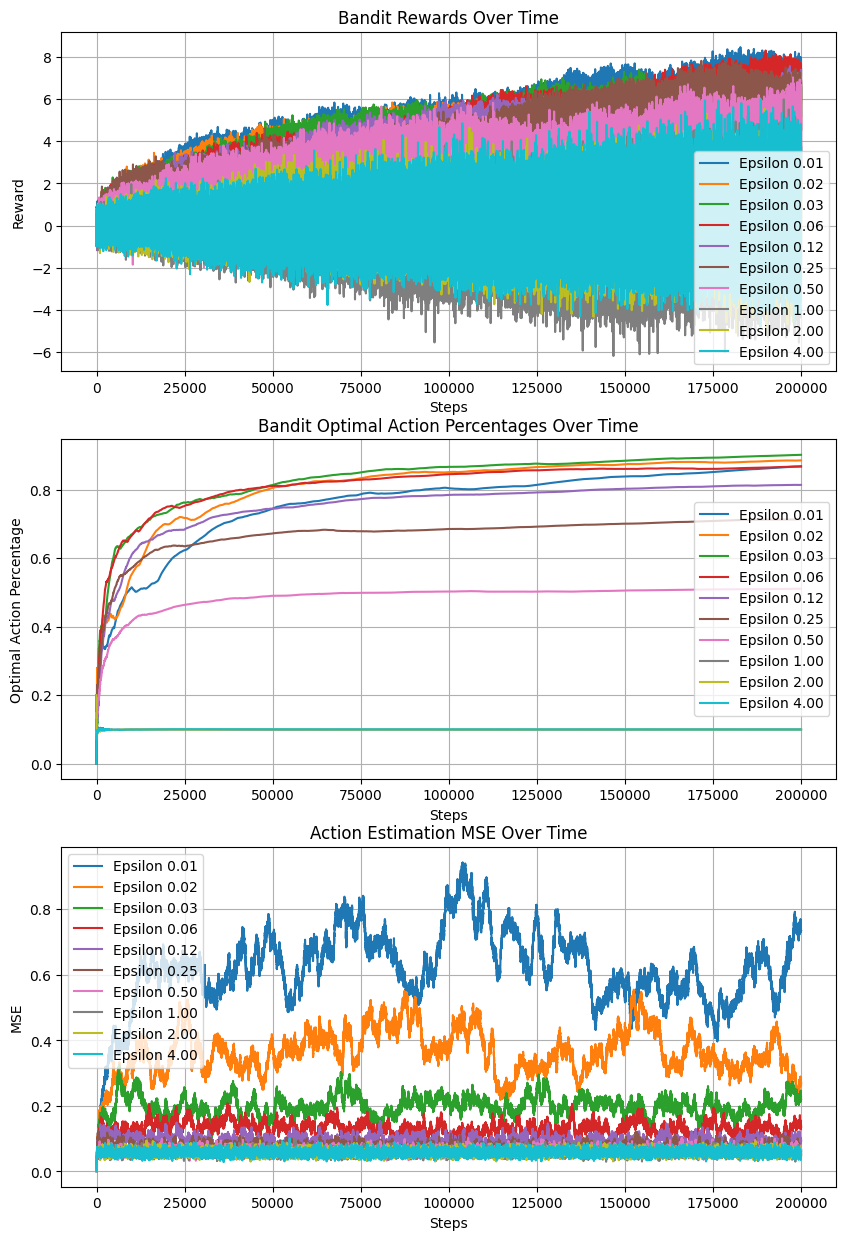

In [251]:
bandit.diagnostic_plots(actor_map, rewards_map, best_action_perct_map, mse_map)

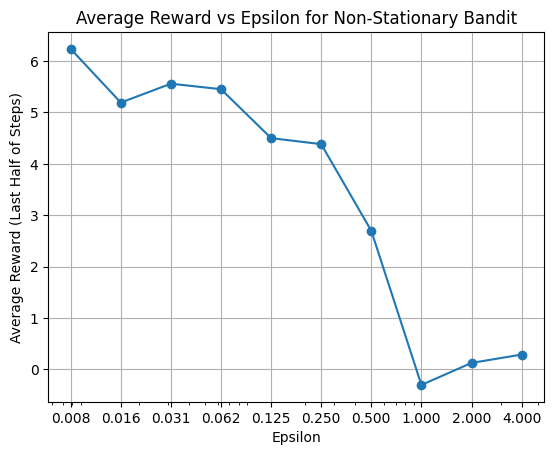

In [261]:
epsilon_rewards = []
for epsilon in epsilons:
    epsilon_rewards.append(rewards_map[f'Epsilon {epsilon:.2f}'].loc[:, int(n_steps_params/2):].mean().mean())

plt.plot(epsilons, epsilon_rewards, marker='o')
plt.xscale('log')
plt.xlabel('Epsilon')
plt.ylabel('Average Reward (Last Half of Steps)')
plt.title('Average Reward vs Epsilon for Non-Stationary Bandit')
plt.xticks(epsilons, [f'{epsilon:.3f}' for epsilon in epsilons])
plt.grid()
plt.show()